In [1]:
# Install wordcloud if not available
!pip install wordcloud

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')
import subprocess
subprocess.run(["pip", "install", "wordcloud"], check=True)

print("TF Version:", tf.__version__)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


TF Version: 2.20.0


In [2]:
# Option 1: Upload manually
from google.colab import files
uploaded = files.upload()  # Upload your spam.csv here

Saving email_spam.csv to email_spam.csv


In [3]:
# Option 2: Download from URL (SMS Spam Collection)
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
!unzip -q smsspamcollection.zip

df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


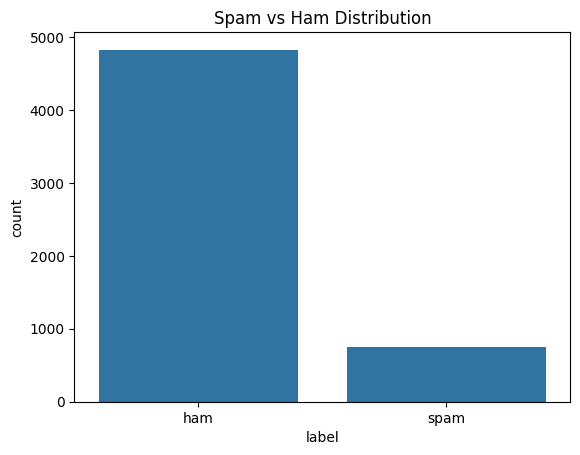

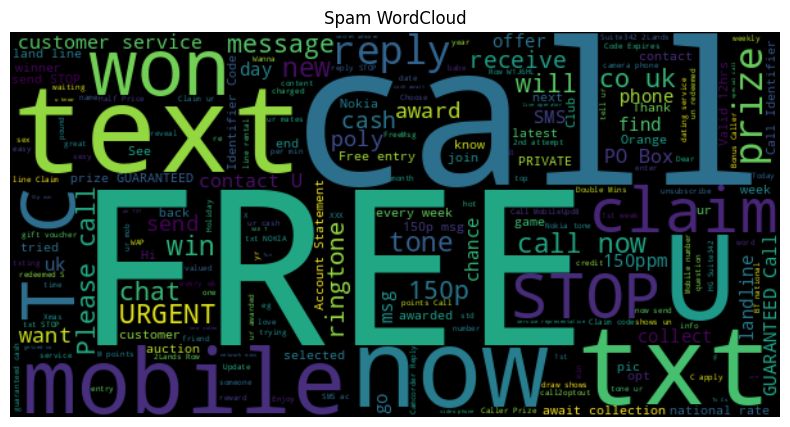

In [4]:
# Shape and info
print(df.shape)
print(df['label'].value_counts())

# Visualize class distribution
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

# WordCloud for Spam
spam_words = ' '.join(df[df['label'] == 'spam']['message'])
wordcloud = WordCloud(width=600, height=300, background_color='black').generate(spam_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_message'] = df['message'].apply(clean_text)

# Encode labels: spam=1, ham=0
df['label_enc'] = df['label'].map({'spam': 1, 'ham': 0})
df.head()

,label,message,clean_message,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,1
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,0


In [6]:
MAX_VOCAB = 10000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_message'])

sequences = tokenizer.texts_to_sequences(df['clean_message'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post', padding='post')

print("Padded shape:", padded.shape)

Padded shape: (5572, 150)


In [7]:
X = padded
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4457, 150) Test: (1115, 150)


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 35s 241ms/step - accuracy: 0.9010 - loss: 0.2821 - val_accuracy: 0.9731 - val_loss: 0.1119 - learning_rate: 0.0010
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - accuracy: 0.9880 - loss: 0.0428 - val_accuracy: 0.9821 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.9975 - loss: 0.0119 - val_accuracy: 0.9821 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9995 - loss: 0.0038 - val_accuracy: 0.9821 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 172ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9910 - val_loss: 0.0558 - learning_rate: 5.0000e-04
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - accuracy: 0.9995 - loss: 9.6942e-04 - val_accuracy: 0.9865 - val_loss: 0.0733 - learning_rate: 5.0000e-04
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 47s 219ms/step - a

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9776 - loss: 0.0858
Test Accuracy: 97.76%


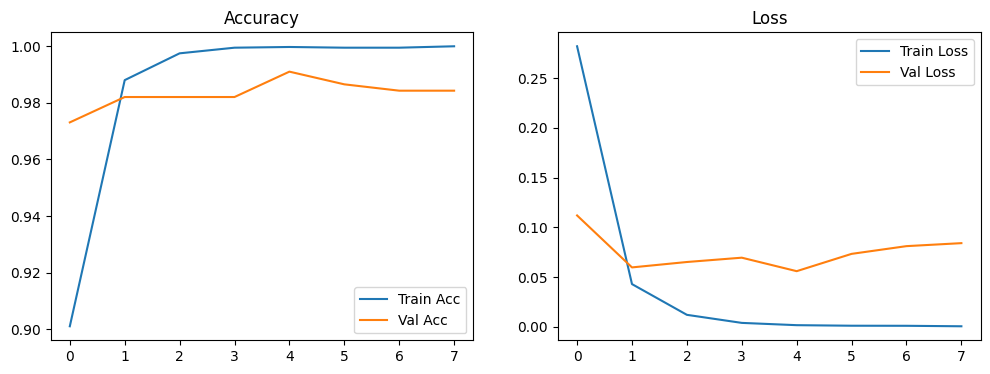

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Plot accuracy & loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()